In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


#  Load Dataset

In [2]:
df = pd.read_csv("used_car_price_prediction_1500_rows_15_columns.csv")

In [3]:
df.head()

,car_id,brand,model,year,km_driven,fuel,seller_type,transmission,owner,mileage_kmpl,engine_cc,max_power_bhp,seats,insurance,selling_price
0,1,Mahindra,Bolero,2023,130355,Petrol,Individual,Manual,Second Owner,25.8,1995,137.7,4,Yes,4171000
1,2,Toyota,Etios,2023,32798,Diesel,Dealer,Manual,Second Owner,14.3,1000,55.4,5,No,2417000
2,3,Kia,Sonet,2025,96649,Diesel,Individual,Manual,First Owner,25.4,800,47.5,5,Yes,2358000
3,4,Tata,Altroz,2021,69887,Diesel,Individual,Manual,First Owner,12.2,1199,79.6,5,No,2859000
4,5,Mahindra,Bolero,2016,24477,Petrol,Individual,Manual,First Owner,22.3,1000,74.8,5,Yes,2258000


In [3]:
print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

First 5 rows:
   car_id     brand   model  year  km_driven    fuel seller_type transmission  \
0       1  Mahindra  Bolero  2023     130355  Petrol  Individual       Manual   
1       2    Toyota   Etios  2023      32798  Diesel      Dealer       Manual   
2       3       Kia   Sonet  2025      96649  Diesel  Individual       Manual   
3       4      Tata  Altroz  2021      69887  Diesel  Individual       Manual   
4       5  Mahindra  Bolero  2016      24477  Petrol  Individual       Manual   

          owner  mileage_kmpl  engine_cc  max_power_bhp  seats insurance  \
0  Second Owner          25.8       1995          137.7      4       Yes   
1  Second Owner          14.3       1000           55.4      5        No   
2   First Owner          25.4        800           47.5      5       Yes   
3   First Owner          12.2       1199           79.6      5        No   
4   First Owner          22.3       1000           74.8      5       Yes   

   selling_price  
0        4171000  
1   

# 2.DATA CLEANING

In [4]:
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (1500, 15)


# 3. Statistical Summary1

In [5]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
            car_id         year      km_driven  mileage_kmpl    engine_cc  \
count  1500.000000  1500.000000    1500.000000   1500.000000  1500.000000   
mean    750.500000  2018.434000   92825.836667     19.884267  1532.894000   
std     433.157015     4.046961   50762.685268      4.581030   536.881503   
min       1.000000  2012.000000    5192.000000     12.000000   800.000000   
25%     375.750000  2015.000000   49039.750000     16.100000  1197.000000   
50%     750.500000  2018.000000   92956.500000     19.800000  1497.000000   
75%    1125.250000  2022.000000  137212.750000     23.800000  1995.000000   
max    1500.000000  2025.000000  179875.000000     28.000000  2494.000000   

       max_power_bhp        seats  selling_price  
count    1500.000000  1500.000000   1.500000e+03  
mean      111.507467     5.239333   3.326091e+06  
std        43.235726     0.750841   1.096805e+06  
min        44.200000     4.000000   1.086000e+06  
25%        76.550000     5.00

# 4. EDA - Univariate Analysis

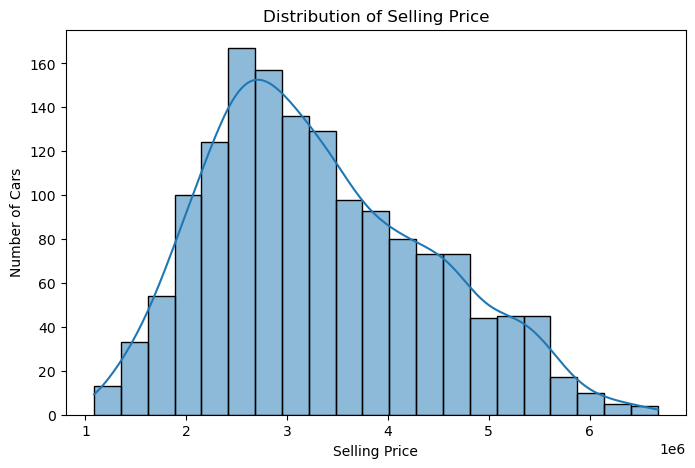

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

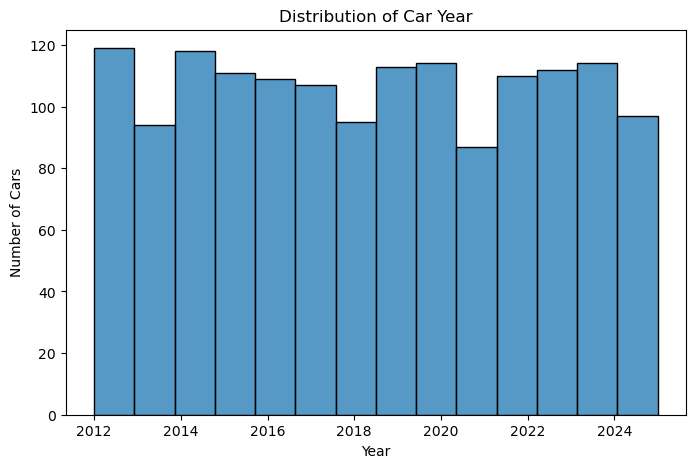

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["year"], bins=14)
plt.title("Distribution of Car Year")
plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.show()

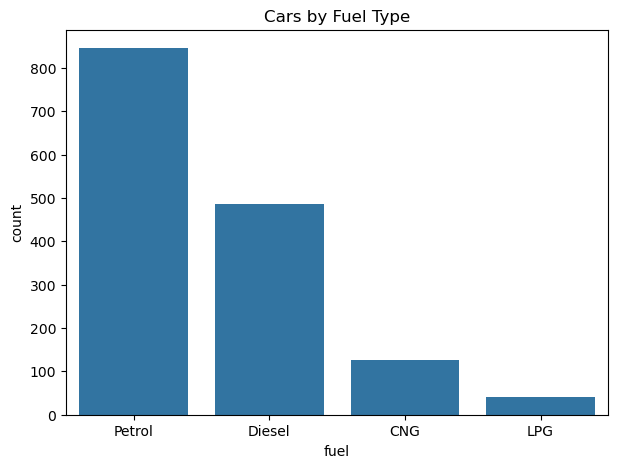

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(x="fuel", data=df)
plt.title("Cars by Fuel Type")
plt.show()

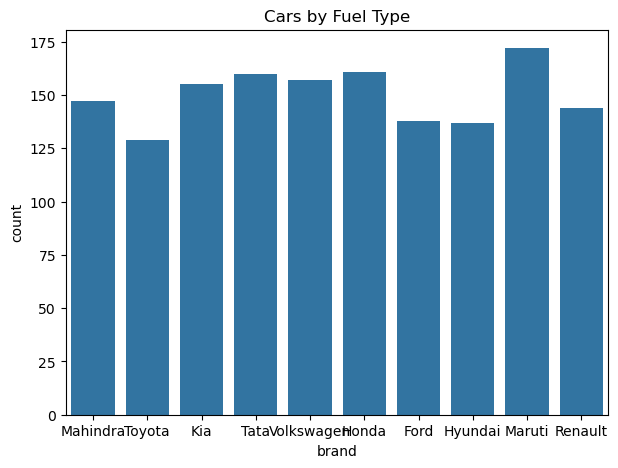

In [28]:
plt.figure(figsize=(7,5))
sns.countplot(x="brand", data=df)
plt.title("Cars by Fuel Type")
plt.show()

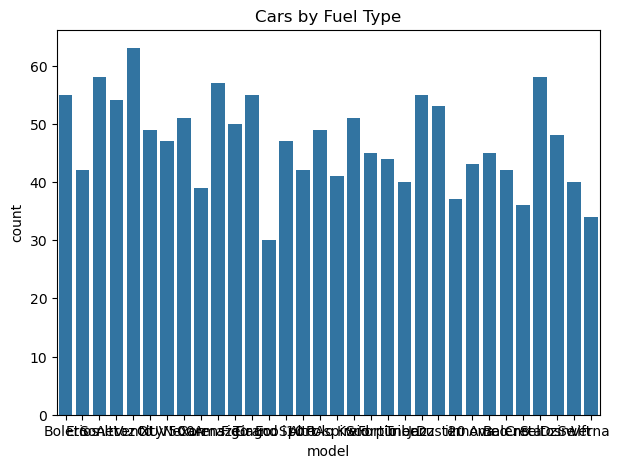

In [29]:
plt.figure(figsize=(7,5))
sns.countplot(x="model", data=df)
plt.title("Cars by Fuel Type")
plt.show()

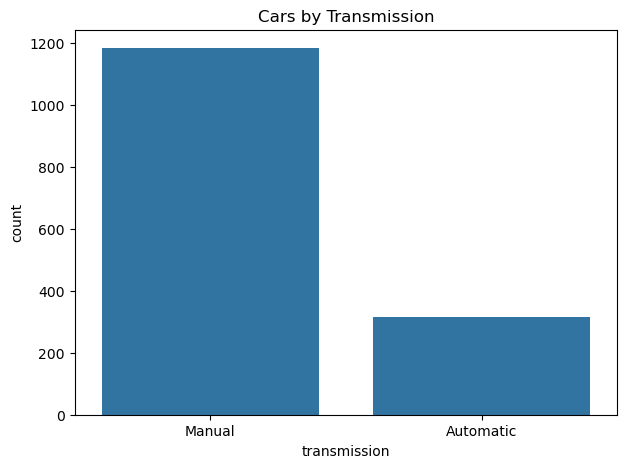

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x="transmission", data=df)
plt.title("Cars by Transmission")
plt.show()


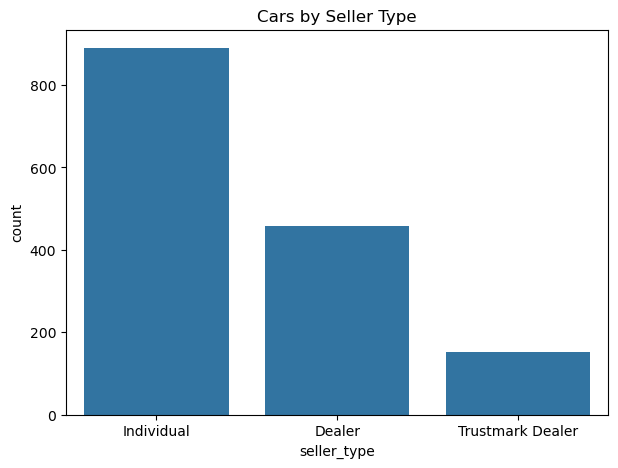

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x="seller_type", data=df)
plt.title("Cars by Seller Type")
plt.show()

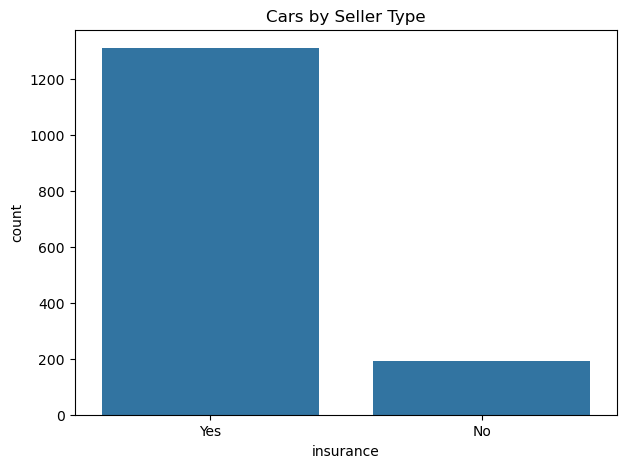

In [32]:
plt.figure(figsize=(7,5))
sns.countplot(x="insurance", data=df)
plt.title("Cars by Seller Type")
plt.show()

# 5. EDA - Bivariate Analysis


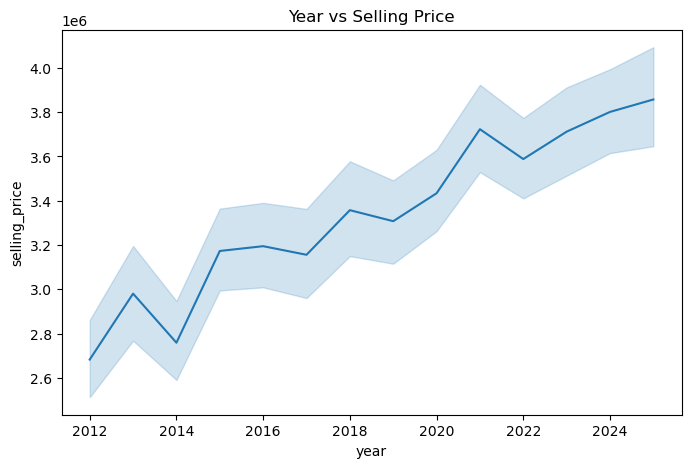

In [5]:
plt.figure(figsize=(8,5))
sns.lineplot(x="year", y="selling_price", data=df)
plt.title("Year vs Selling Price")
plt.show()

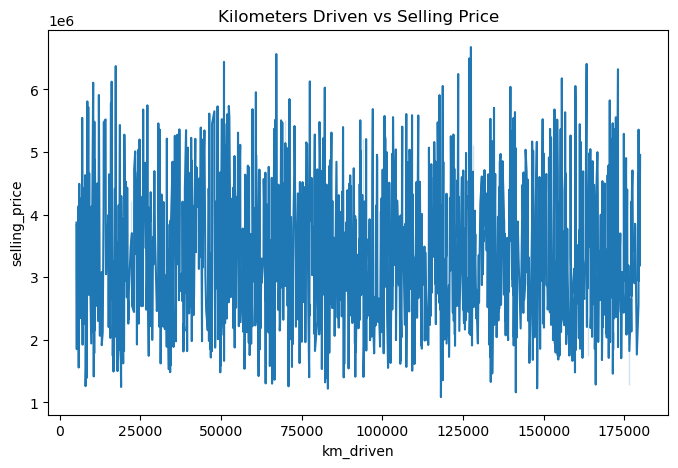

In [8]:
plt.figure(figsize=(8,5))
sns.lineplot(x="km_driven", y="selling_price", data=df)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

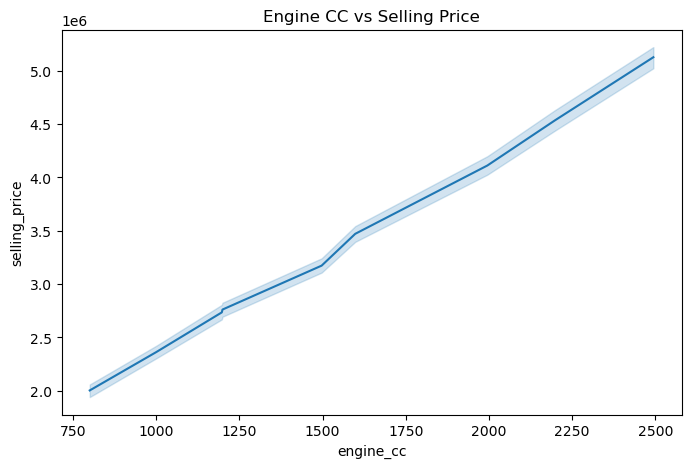

In [9]:
plt.figure(figsize=(8,5))
sns.lineplot(x="engine_cc", y="selling_price", data=df)
plt.title("Engine CC vs Selling Price")
plt.show()

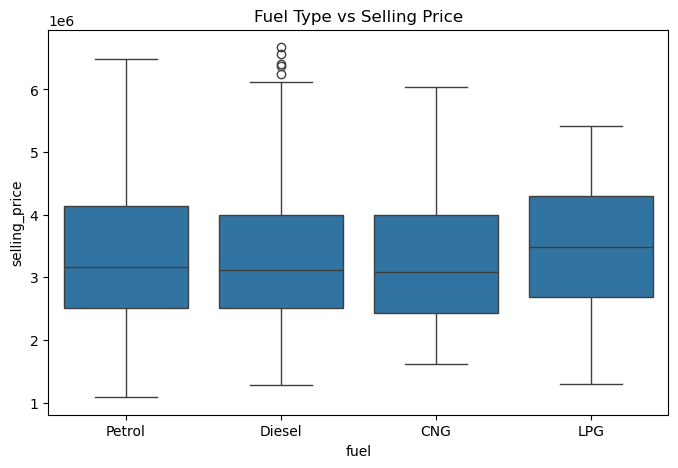

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fuel", y="selling_price", data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

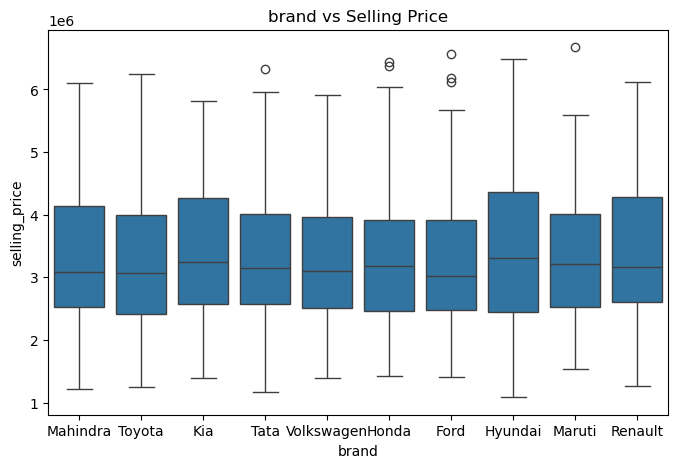

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="brand", y="selling_price", data=df)
plt.title("brand vs Selling Price")
plt.show()

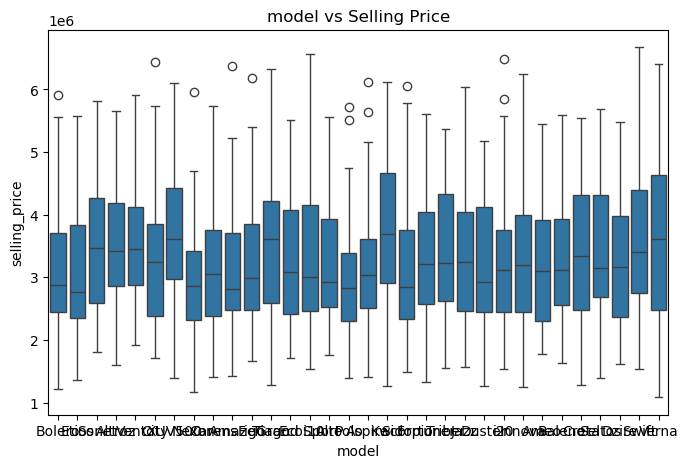

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="model", y="selling_price", data=df)
plt.title("model vs Selling Price")
plt.show()

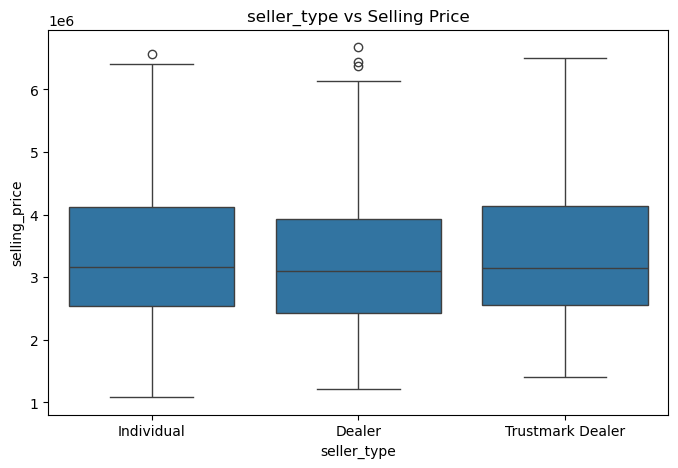

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="seller_type", y="selling_price", data=df)
plt.title("seller_type vs Selling Price")
plt.show()

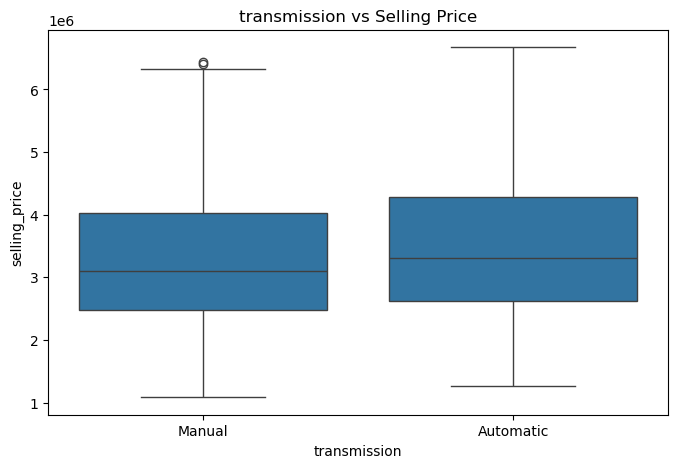

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="transmission", y="selling_price", data=df)
plt.title("transmission vs Selling Price")
plt.show()

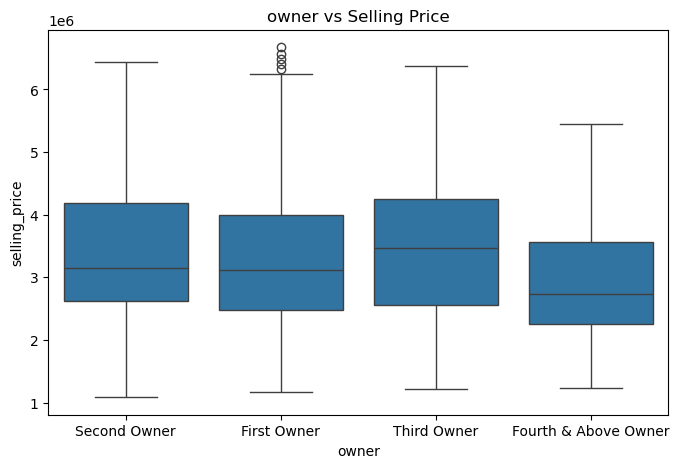

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="owner", y="selling_price", data=df)
plt.title("owner vs Selling Price")
plt.show()

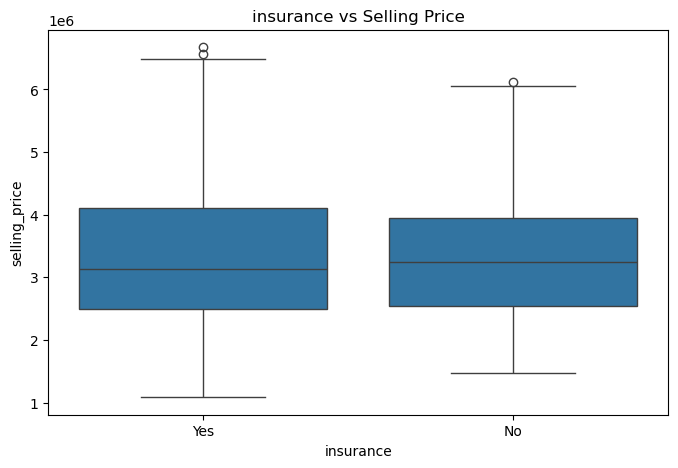

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="insurance", y="selling_price", data=df)
plt.title("insurance vs Selling Price")
plt.show()

# 6. Correlation Heatmap

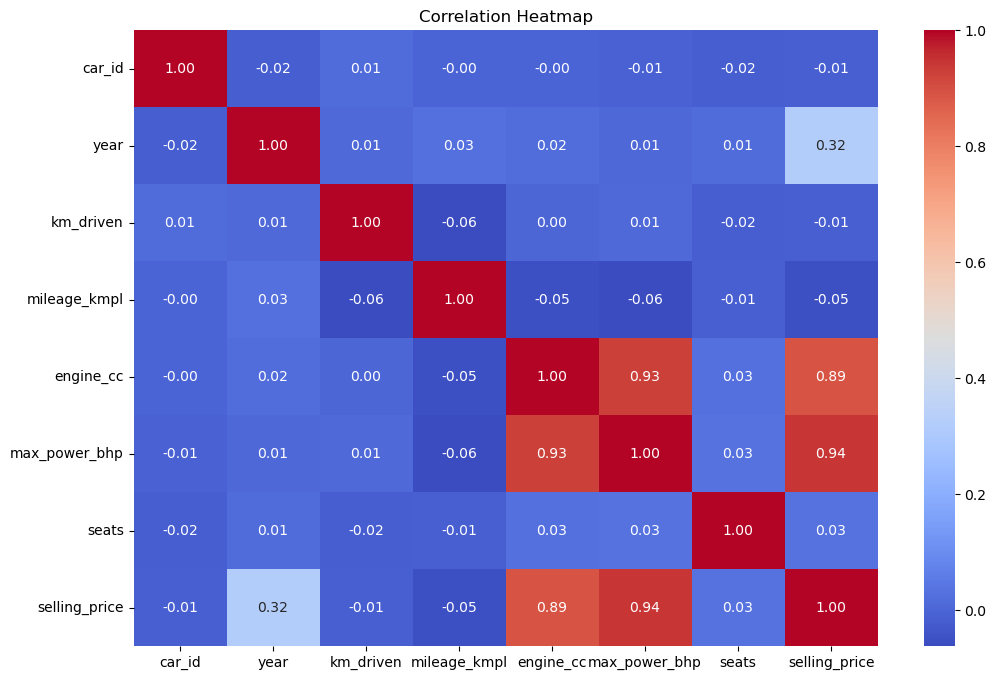

In [15]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# 7. Outlier Detection

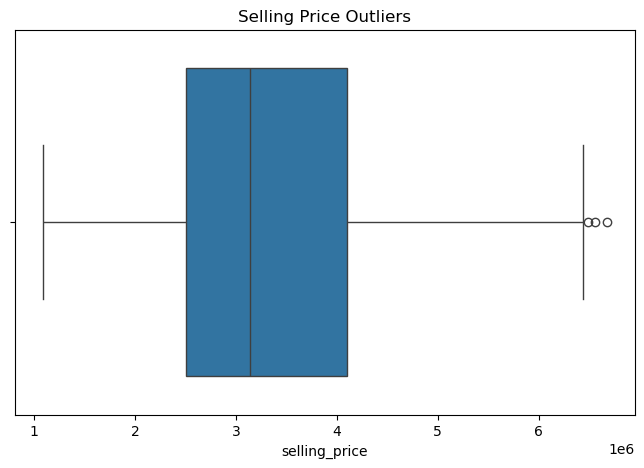

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["selling_price"])
plt.title("Selling Price Outliers")
plt.show()

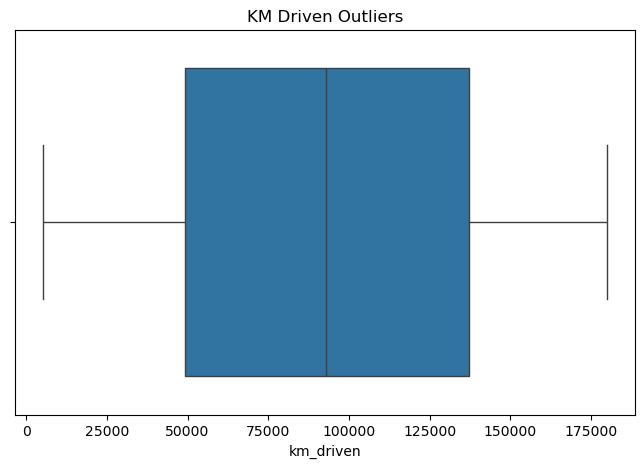

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["km_driven"])
plt.title("KM Driven Outliers")
plt.show()

# 8. Features and Target

In [18]:
X = df.drop(columns=["selling_price", "car_id"])
y = df["selling_price"]


In [19]:
df.head()

,car_id,brand,model,year,km_driven,fuel,seller_type,transmission,owner,mileage_kmpl,engine_cc,max_power_bhp,seats,insurance,selling_price
0,1,Mahindra,Bolero,2023,130355,Petrol,Individual,Manual,Second Owner,25.8,1995,137.7,4,Yes,4171000
1,2,Toyota,Etios,2023,32798,Diesel,Dealer,Manual,Second Owner,14.3,1000,55.4,5,No,2417000
2,3,Kia,Sonet,2025,96649,Diesel,Individual,Manual,First Owner,25.4,800,47.5,5,Yes,2358000
3,4,Tata,Altroz,2021,69887,Diesel,Individual,Manual,First Owner,12.2,1199,79.6,5,No,2859000
4,5,Mahindra,Bolero,2016,24477,Petrol,Individual,Manual,First Owner,22.3,1000,74.8,5,Yes,2258000


In [20]:
df.tail()

,car_id,brand,model,year,km_driven,fuel,seller_type,transmission,owner,mileage_kmpl,engine_cc,max_power_bhp,seats,insurance,selling_price
1495,1496,Mahindra,Bolero,2022,179718,Petrol,Individual,Manual,First Owner,16.7,1497,89.3,4,Yes,3179000
1496,1497,Volkswagen,Polo,2021,81623,Petrol,Dealer,Manual,Fourth & Above Owner,25.1,1497,97.4,5,Yes,3074000
1497,1498,Renault,Duster,2020,136004,Diesel,Individual,Manual,Second Owner,13.1,1000,72.3,5,No,2450000
1498,1499,Hyundai,Verna,2015,58687,Petrol,Trustmark Dealer,Automatic,Second Owner,24.7,1995,153.9,5,Yes,4133000
1499,1500,Tata,Altroz,2015,73312,Diesel,Dealer,Manual,First Owner,21.6,1199,73.6,5,Yes,2324000


In [21]:
df.shape

(1500, 15)

In [22]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage_kmpl', 'engine_cc', 'max_power_bhp',
       'seats', 'insurance', 'selling_price'],
      dtype='object')

In [23]:
df.value_counts

<bound method DataFrame.value_counts of       car_id       brand   model  year  km_driven    fuel       seller_type  \
0          1    Mahindra  Bolero  2023     130355  Petrol        Individual   
1          2      Toyota   Etios  2023      32798  Diesel            Dealer   
2          3         Kia   Sonet  2025      96649  Diesel        Individual   
3          4        Tata  Altroz  2021      69887  Diesel        Individual   
4          5    Mahindra  Bolero  2016      24477  Petrol        Individual   
...      ...         ...     ...   ...        ...     ...               ...   
1495    1496    Mahindra  Bolero  2022     179718  Petrol        Individual   
1496    1497  Volkswagen    Polo  2021      81623  Petrol            Dealer   
1497    1498     Renault  Duster  2020     136004  Diesel        Individual   
1498    1499     Hyundai   Verna  2015      58687  Petrol  Trustmark Dealer   
1499    1500        Tata  Altroz  2015      73312  Diesel            Dealer   

     transm

# 9. Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1200, 13)
Testing data: (300, 13)


# 10. Feature Types

In [33]:
categorical_features = [
    "brand", "model", "fuel", "seller_type",
    "transmission", "owner", "insurance"
]

In [34]:
numerical_features = [
    "year", "km_driven", "mileage_kmpl",
    "engine_cc", "max_power_bhp", "seats"
]


# 11. Preprocessing

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_features),
        ("numerical",
         StandardScaler(),
         numerical_features)
    ]
)

# 12. Linear Regression

In [36]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("\n===== LINEAR REGRESSION =====")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)



===== LINEAR REGRESSION =====
MAE: 66348.90002716299
MSE: 7070594240.153359
RMSE: 84086.82560397532
R2 Score: 0.9940373499266015


# 13. Random Forest

In [39]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\n===== RANDOM FOREST =====")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)



===== RANDOM FOREST =====
MAE: 96167.66666666667
MSE: 15108929690.5
RMSE: 122918.38629960938
R2 Score: 0.987258601233766


# 14. Model Comparison


===== MODEL COMPARISON =====
               Model           MAE           RMSE  R2 Score
0  Linear Regression  66348.900027   84086.825604  0.994037
1      Random Forest  96167.666667  122918.386300  0.987259


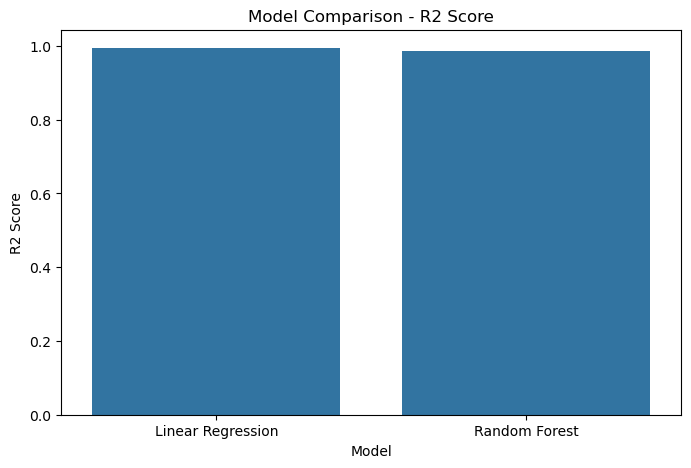

In [40]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

print("\n===== MODEL COMPARISON =====")
print(results)

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=results)
plt.title("Model Comparison - R2 Score")
plt.show()

# 15. Actual vs Predicted

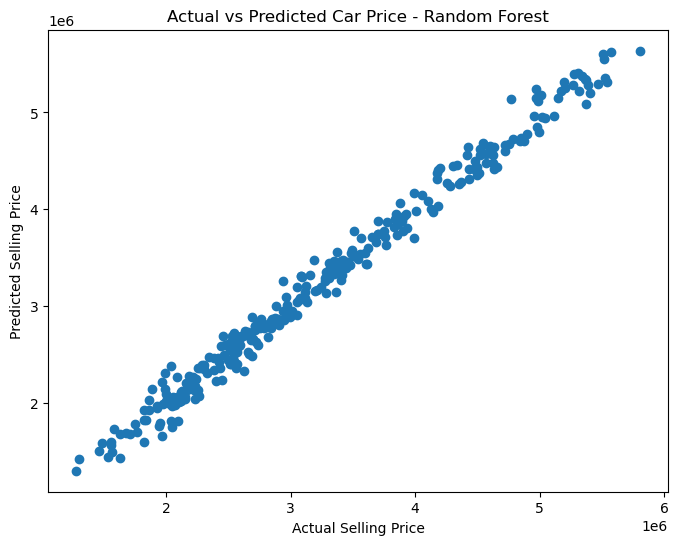

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Price - Random Forest")
plt.show()

# 16. New Car Price Prediction

In [42]:
new_car = pd.DataFrame({
    "brand": ["Hyundai"],
    "model": ["Creta"],
    "year": [2021],
    "km_driven": [35000],
    "fuel": ["Petrol"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],
    "owner": ["First Owner"],
    "mileage_kmpl": [17.5],
    "engine_cc": [1497],
    "max_power_bhp": [113.8],
    "seats": [5],
    "insurance": ["Yes"]
})

predicted_price = rf_model.predict(new_car)

print("\n===== NEW CAR PREDICTION =====")
print("Predicted Used Car Price: ₹", round(predicted_price[0], 2))



===== NEW CAR PREDICTION =====
Predicted Used Car Price: ₹ 3621160.0
